# Лабораторная работа 3: Обучение с учителем. Задача классификации

**Датасет:** `asteroids_cleaned.csv`
**Целевой признак:** `hazardous` (0 — безопасный, 1 — опасный)
**Тип задачи:** Бинарная классификация
**Модели:** Logistic Regression, kNN, Custom kNN, Naive Bayes, SVM
**Оценка:** Hold-out (60 / 20 / 20) + StratifiedKFold(10)
**Пользовательские функции:** определены инлайн после импортов

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from imblearn.over_sampling import SMOTE

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')


RANDOM_STATE = 42

In [ ]:
# Pipeline helper
def make_pipeline(model, scale=True, balance=True):
    steps = []
    
    # Стандартизация признаков (всегда идет первой)
    if scale:
        steps.append(('scaler', StandardScaler()))
        
    # Балансировка SMOTE (применяется автоматически только к обучающей части)
    if balance:
        steps.append(('smote', SMOTE(random_state=RANDOM_STATE)))
        
    # Сама модель с фиксированным именем 'model' для сохранения совместимости с 'model__C'
    steps.append(('model', model))
    
    # Используем Pipeline из imblearn, чтобы SMOTE не трогал валидационные данные
    return Pipeline(steps)

# Экспоненциальное ядро для SVM
def exponential_kernel(gamma=0.1):
    # Используем sklearn euclidean_distances — избегает 3D-массива в памяти
    from sklearn.metrics.pairwise import euclidean_distances
    def kernel(X, Y):
        return np.exp(-gamma * euclidean_distances(X, Y))
    return kernel

# Балансировка через SMOTE
def balance_train_smote(X_train, y_train, random_state=RANDOM_STATE):
    sm = SMOTE(random_state=random_state)
    return sm.fit_resample(X_train, y_train)

# Sklearn метрики (macro)
def sklearn_metrics(y_true, y_pred):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1':        f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

# Строка для hold-out таблицы
def holdout_row(name, train_m, test_m):
    return {
        'Классификатор': name,
        'Train F1':        round(train_m['F1'], 4),
        'Train Accuracy':  round(train_m['Accuracy'], 4),
        'Train Precision': round(train_m['Precision'], 4),
        'Train Recall':    round(train_m['Recall'], 4),
        'Test F1':         round(test_m['F1'], 4),
        'Test Accuracy':   round(test_m['Accuracy'], 4),
        'Test Precision':  round(test_m['Precision'], 4),
        'Test Recall':     round(test_m['Recall'], 4),
    }

# Обучение и оценка модели
def evaluate_model(pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    y_tr_pred  = pipeline.predict(X_train)
    y_tst_pred = pipeline.predict(X_test)
    return pipeline, y_tr_pred, y_tst_pred, sklearn_metrics(y_train, y_tr_pred), sklearn_metrics(y_test, y_tst_pred)

# Подбор гиперпараметров (Grid + Random + Optuna)
def _arr(X, idx):
    return X.iloc[idx] if hasattr(X, 'iloc') else X[idx]

def run_searches(base_pipeline, param_grid, param_distributions,
                 optuna_builder, X_search, y_search, X_val, y_val,
                 n_splits=3, n_iter=20, n_trials=20):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    candidates = {}

    gs = GridSearchCV(base_pipeline, param_grid, scoring='f1_macro', cv=skf, n_jobs=-1)
    gs.fit(X_search, y_search)
    candidates['GridSearch'] = gs.best_estimator_

    rs = RandomizedSearchCV(base_pipeline, param_distributions, scoring='f1_macro',
                            cv=skf, n_iter=n_iter, n_jobs=-1, random_state=RANDOM_STATE)
    rs.fit(X_search, y_search)
    candidates['RandomSearch'] = rs.best_estimator_

    def objective(trial):
        est = optuna_builder(trial)
        scores = []
        for tr_idx, val_idx in skf.split(
            X_search if not hasattr(X_search, 'values') else X_search.values,
            y_search if not hasattr(y_search, 'values') else y_search.values,
        ):
            Xtr, Xvl = _arr(X_search, tr_idx), _arr(X_search, val_idx)
            ytr = _arr(y_search, tr_idx)
            yvl = _arr(y_search, val_idx)
            est.fit(Xtr, ytr)
            scores.append(f1_score(yvl, est.predict(Xvl), average='macro', zero_division=0))
        return float(np.mean(scores))

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    best_opt = optuna_builder(study.best_trial)
    best_opt.fit(X_search, y_search)
    candidates['Optuna'] = best_opt

    return candidates

# Выбор лучшей модели по F1 на валидации
def choose_best_by_validation(candidates, X_train, y_train, X_val, y_val):
    best_name, best_score, best_model = None, -1, None
    scores = {}
    for name, model in candidates.items():
        model.fit(X_train, y_train)
        score = f1_score(y_val, model.predict(X_val), average='macro', zero_division=0)
        scores[name] = round(score, 4)
        if score > best_score:
            best_score, best_name, best_model = score, name, model
    return best_model, best_name, scores

# Кросс-валидация
def cross_val_metrics(factory_fn, X, y, balance_train=False, balance_fn=None, n_splits=10):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
    y_arr = y.values if hasattr(y, 'values') else np.asarray(y)
    rows = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_arr, y_arr), start=1):
        Xtr, Xvl = X_arr[tr_idx], X_arr[val_idx]
        ytr, yvl = y_arr[tr_idx], y_arr[val_idx]
        if balance_train and balance_fn is not None:
            Xtr, ytr = balance_fn(Xtr, ytr)
        model = factory_fn()
        model.fit(Xtr, ytr)
        m = sklearn_metrics(yvl, model.predict(Xvl))
        m['Fold'] = fold
        rows.append(m)
    fold_df = pd.DataFrame(rows)
    summary = {
        col: f"{fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}"
        for col in ['F1', 'Accuracy', 'Precision', 'Recall']
    }
    return fold_df, summary

# Визуализация + матрица ошибок
def add_confusion_plot(model, X_test, y_test, title, labels=None):
    y_pred = model.predict(X_test)
    lbl = labels if labels is not None else np.unique(y_test)
    cm = confusion_matrix(y_test, y_pred, labels=lbl)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=lbl).plot(ax=ax, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_model_results(model, X_test, y_test, title, labels=None):
    m = sklearn_metrics(y_test, model.predict(X_test))
    print(f"{title}:")
    for k, v in m.items():
        print(f"  {k}: {v:.4f}")
    add_confusion_plot(model, X_test, y_test, f"Confusion Matrix: {title}", labels=labels)

# Сравнение sklearn vs пользовательских метрик
def compare_metrics(y_true, y_pred):
    sk = sklearn_metrics(y_true, y_pred)
    return {
        'sk F1':        round(sk['F1'], 4),
        'my F1':        round(f1_custom(y_true, y_pred), 4),
        'sk Accuracy':  round(sk['Accuracy'], 4),
        'my Accuracy':  round(accuracy_custom(y_true, y_pred), 4),
        'sk Precision': round(sk['Precision'], 4),
        'my Precision': round(precision_custom(y_true, y_pred), 4),
        'sk Recall':    round(sk['Recall'], 4),
        'my Recall':    round(recall_custom(y_true, y_pred), 4),
    }


# ════════════════════
# Пользовательский kNN
# ════════════════════
class CustomKNNClassifier(BaseEstimator, ClassifierMixin):
    '''k-ближайших соседей (векторизованная numpy реализация, sklearn API).

    Евклидово расстояние: ||a-b||² = ||a||² + ||b||² - 2·a·b^T
    '''
    def __init__(self, n_neighbors=5, metric='euclidean'):
        self.n_neighbors = n_neighbors
        self.metric = metric

    def fit(self, X, y):
        self.X_train_ = np.array(X, dtype=np.float64)
        self.y_train_ = np.array(y)
        self.classes_  = np.unique(y)
        self._X_sq_    = np.sum(self.X_train_ ** 2, axis=1)
        return self

    def _euclidean(self, batch):
        A2 = np.sum(batch ** 2, axis=1, keepdims=True)
        d2 = A2 + self._X_sq_ - 2.0 * (batch @ self.X_train_.T)
        np.maximum(d2, 0.0, out=d2)
        return np.sqrt(d2)

    def _manhattan(self, batch):
        n = batch.shape[0]
        d = np.empty((n, self.X_train_.shape[0]), dtype=np.float64)
        for i in range(n):
            d[i] = np.sum(np.abs(batch[i] - self.X_train_), axis=1)
        return d

    def predict(self, X, batch_size=500):
        X = np.array(X, dtype=np.float64)
        n = X.shape[0]
        out = np.empty(n, dtype=self.y_train_.dtype)
        for s in range(0, n, batch_size):
            e = min(s + batch_size, n)
            b = X[s:e]
            dists = self._euclidean(b) if self.metric == 'euclidean' else self._manhattan(b)
            k_idx = np.argpartition(dists, self.n_neighbors, axis=1)[:, :self.n_neighbors]
            for i, idx in enumerate(k_idx):
                labels, counts = np.unique(self.y_train_[idx], return_counts=True)
                out[s + i] = labels[np.argmax(counts)]
        return out

    def score(self, X, y, batch_size=500):
        return float(np.mean(self.predict(X, batch_size) == np.asarray(y)))

# ════════════════════════
# Пользовательские метрики
# ════════════════════════
def _cm_raw(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    classes = np.unique(np.concatenate([y_true, y_pred]))
    idx = {c: i for i, c in enumerate(classes)}
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[idx[t], idx[p]] += 1
    return cm, classes

def accuracy_custom(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.sum(y_true == y_pred) / len(y_true))

def precision_custom(y_true, y_pred):
    cm, classes = _cm_raw(y_true, y_pred)
    vals = []
    for i in range(len(classes)):
        tp = cm[i, i]; fp = cm[:, i].sum() - tp
        vals.append(tp / (tp + fp) if (tp + fp) > 0 else 0.0)
    return float(np.mean(vals))

def recall_custom(y_true, y_pred):
    cm, classes = _cm_raw(y_true, y_pred)
    vals = []
    for i in range(len(classes)):
        tp = cm[i, i]; fn = cm[i, :].sum() - tp
        vals.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
    return float(np.mean(vals))

def f1_custom(y_true, y_pred):
    p = precision_custom(y_true, y_pred)
    r = recall_custom(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


## 1. Загрузка и подготовка данных

### 2.1 Загрузка датасета

In [5]:
df = pd.read_csv('asteroids_cleaned.csv')
df.head()

,year,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,2011,0.035813,56014.078517,1.024333e+06,26.1,0
1,2020,0.068240,7864.348060,3.268186e+07,24.7,0
2,2016,0.124177,55257.544508,6.538636e+07,23.4,0
3,2013,0.043057,41531.404722,1.260796e+07,25.7,0
4,2016,0.311918,67639.394481,7.130590e+07,21.4,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88534 entries, 0 to 88533
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                88534 non-null  int64  
 1   est_diameter_max    88534 non-null  float64
 2   relative_velocity   88534 non-null  float64
 3   miss_distance       88534 non-null  float64
 4   absolute_magnitude  88534 non-null  float64
 5   hazardous           88534 non-null  int64  
dtypes: float64(4), int64(2)
memory usage: 4.1 MB


### 2.2 Целевой признак и предикторы

| Признак | Тип | Описание |
|---------|-----|---------|
| `year` | int | Год обнаружения |
| `est_diameter_max` | float | Максимальный оценочный диаметр (км) |
| `relative_velocity` | float | Относительная скорость (км/ч) |
| `miss_distance` | float | Расстояние до Земли (км) |
| `absolute_magnitude` | float | Абсолютная звёздная величина |
| **`hazardous`** | **int** | **Целевой признак** (0 = не опасен, 1 = опасен) |

**Тип задачи**: Бинарная классификация (два класса: 0 и 1).


In [7]:
target = 'hazardous'
X = df.drop(columns=[target])
y = df[target]

### 2.3 Проверка баланса классов

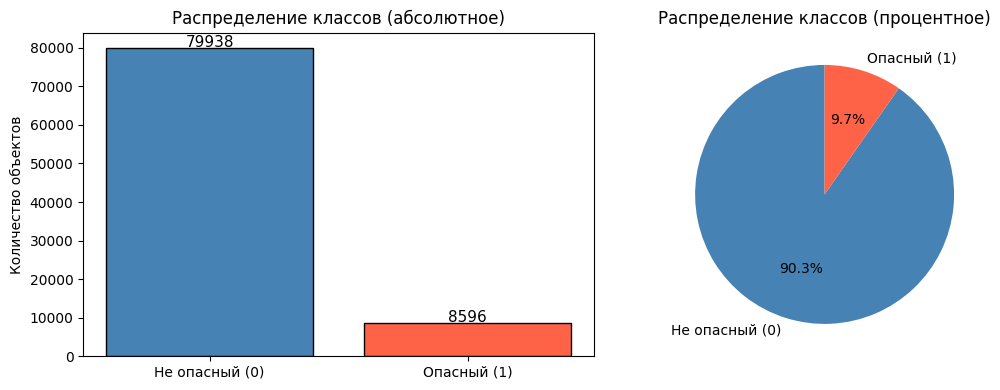

In [8]:
counts = pd.Series(y).value_counts().sort_index()
classes = np.sort(y.unique())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["Не опасный (0)", "Опасный (1)"], counts.values,
            color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Распределение классов (абсолютное)")
axes[0].set_ylabel("Количество объектов")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha="center", fontsize=11)

axes[1].pie(counts.values, labels=["Не опасный (0)", "Опасный (1)"],
            autopct="%1.1f%%", colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Распределение классов (процентное)")
plt.tight_layout()
plt.show()


Присутствует дисбаланс классов (примерно 90% на 10%), требуется балансировка

Использована **стратифицированная** разбивка (`stratify=y`) — каждая выборка
сохраняет исходную пропорцию классов.

Алгоритм двух последовательных разбиений:
1. 60% train + 40% temp
2. temp -> 50% val + 50% test (итого 20% + 20%)

В итоге получаем: 60% train + 20% val + 20% test

Балансировка только на обучающей выборке:

| Модель | Обучающие данные | Способ компенсации дисбаланса |
|--------|-----------------|-------------------------------|
| Все модели (LR, NB, SVM) | `X_train_bal`  | SMOTE (Синтетические образцы миноритарного класса) |
| kNN (sklearn + custom) | `X_train_full` | — (дубликаты на расстоянии 0 искажают метрику расстояния) |

In [9]:
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

total = len(y)
print(f"Train : {len(y_train_full):>6}  ({len(y_train_full)/total:.1%})")
print(f"Val   : {len(y_val):>6}  ({len(y_val)/total:.1%})")
print(f"Test  : {len(y_test):>6}  ({len(y_test)/total:.1%})")
print()
print("Доля класса 1 (опасный) в каждой выборке:")
for name, yy in [("Train", y_train_full*100), ("Val", y_val*100), ("Test", y_test*100)]:
    print(f"  {name}: {yy.mean():.3f}")

Train :  53120  (60.0%)
Val   :  17707  (20.0%)
Test  :  17707  (20.0%)

Доля класса 1 (опасный) в каждой выборке:
  Train: 9.710
  Val: 9.708
  Test: 9.708


## 3. Решение задачи классификации

### 3.1. Logistic Regression

Линейный классификатор, чувствителен к масштабу признаков, модель не запоминает отдельные точки, корректно работает с дубликатами.
В make_pipline использвуем масштабирование и балансировку smote

c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=20. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Validation scores: {'GridSearch': 0.6615, 'RandomSearch': 0.6615, 'Optuna': 0.6614}
Лучший метод: GridSearch
Logistic Regression:
  Accuracy: 0.7888
  Precision: 0.6497
  Recall: 0.8563
  F1: 0.6661


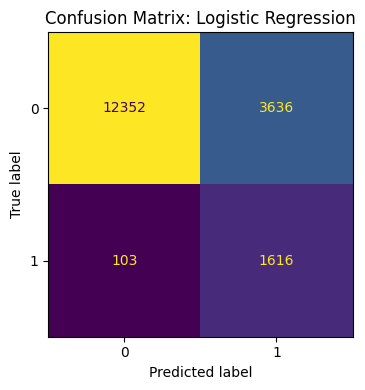

In [11]:
log_reg_pipe = make_pipeline(
    model=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    scale=True,
    balance=True
)

log_reg_candidates = run_searches(
    base_pipeline=log_reg_pipe,
    param_grid={
        'model__C': [0.03, 0.1, 0.3, 1.0, 3.0],
    },
    param_distributions={
        'model__C': [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
    },
    optuna_builder=lambda trial: make_pipeline(
        LogisticRegression(
            C=trial.suggest_float('C', 0.03, 10.0, log=True),
            max_iter=5000,
            random_state=RANDOM_STATE,
        ),
        scale=True,
        balance=True
    ),
    X_search=X_train_full,
    y_search=y_train_full,
    X_val=X_val,
    y_val=y_val,
    n_trials=15,
)

model_log_reg, log_reg_method, log_reg_scores = choose_best_by_validation(
    log_reg_candidates, X_train_full, y_train_full, X_val, y_val
)

model_log_reg, y_log_train, y_log_test, log_train_metrics, log_test_metrics = evaluate_model(
    model_log_reg, X_train_full, y_train_full, X_test, y_test
)

print('Validation scores:', log_reg_scores)
print('Лучший метод:', log_reg_method)
plot_model_results(model_log_reg, X_test, y_test, 'Logistic Regression', labels=classes)

### 3.2. kNN из Scikit-learn

Классификация по ближайшим соседям, чувствительна к масштабу и дубликатам. Для балансировки использовали SMOTE в make_pipeline и параметр weights='distance', вместе они дают лучшие результаты

Исследовние различных методов расстояния и их влияние на классификацию. Для удобства оценки используем F1 macro, так как он оценивает способность алгоритма разделять оба класса одновременно.

,k,Accuracy,F1 macro
0,5,0.855989,0.708605
1,7,0.847800,0.704895
2,9,0.841983,0.703426
3,11,0.836562,0.699737
4,13,0.830914,0.695879
5,15,0.827243,0.693936
6,17,0.824759,0.693008
7,19,0.822951,0.692779
8,21,0.819789,0.690518


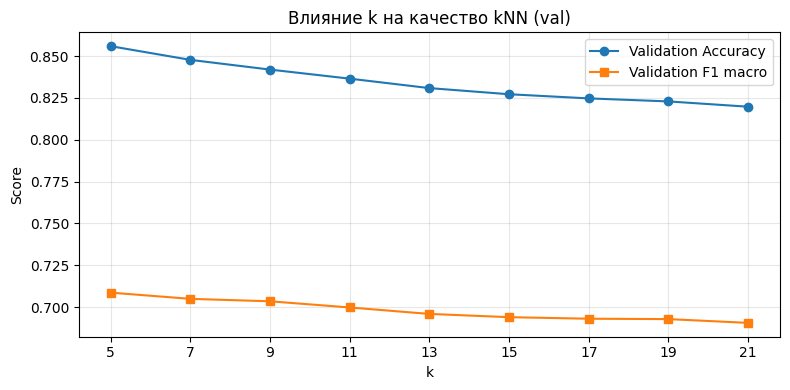

In [ ]:
k_values = list(range(5, 22, 2))
knn_curve_rows = []
for k in k_values:
    candidate = make_pipeline(
        KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance'),
        scale=True,
        balance=True
    )
    candidate.fit(X_train_full, y_train_full)
    pred_val = candidate.predict(X_val)
    knn_curve_rows.append({
        'k': k,
        'Accuracy': accuracy_score(y_val, pred_val),
        'F1 macro': f1_score(y_val, pred_val, average='macro', zero_division=0),
    })

df_knn_curve = pd.DataFrame(knn_curve_rows)
display(df_knn_curve)

plt.figure(figsize=(8, 4))
plt.plot(df_knn_curve['k'], df_knn_curve['Accuracy'], marker='o', label='Validation Accuracy')
plt.plot(df_knn_curve['k'], df_knn_curve['F1 macro'], marker='s', label='Validation F1 macro')
plt.xlabel('k')
plt.ylabel('Score')
plt.title('Влияние k на качество kNN (val)')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Итоговая модель kNN

Validation scores: {'GridSearch': 0.7132, 'RandomSearch': 0.7132, 'Optuna': 0.7132}
Лучший метод: GridSearch
kNN (sklearn):
  Accuracy: 0.8599
  Precision: 0.6789
  Recall: 0.8142
  F1: 0.7151


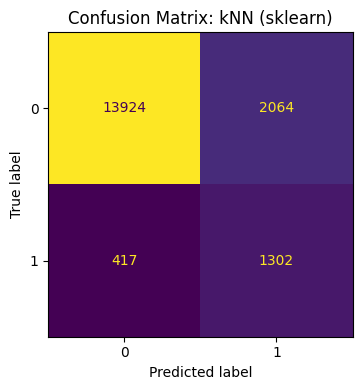

In [13]:
knn_pipe = make_pipeline(
    KNeighborsClassifier(),
    scale=True,
    balance=True
)

knn_candidates = run_searches(
    base_pipeline=knn_pipe,
    param_grid={
        'model__n_neighbors': [5, 7, 9, 11, 13, 15],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan'],
    },
    param_distributions={
        'model__n_neighbors': [5, 7, 9, 11, 13, 15, 17, 19],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan'],
    },
    optuna_builder=lambda trial: make_pipeline(
        KNeighborsClassifier(
            n_neighbors=trial.suggest_int('n_neighbors', 5, 19, step=2),
            weights=trial.suggest_categorical('weights', ['uniform', 'distance']),
            metric=trial.suggest_categorical('metric', ['euclidean', 'manhattan']),
        ),
        scale=True,
        balance=True
    ),
    X_search=X_train_full,
    y_search=y_train_full,
    X_val=X_val,
    y_val=y_val,
    n_trials=15,
)

model_knn, knn_method, knn_scores = choose_best_by_validation(
    knn_candidates, X_train_full, y_train_full, X_val, y_val
)

model_knn, y_knn_train, y_knn_test, knn_train_metrics, knn_test_metrics = evaluate_model(
    model_knn, X_train_full, y_train_full, X_test, y_test
)

print('Validation scores:', knn_scores)
print('Лучший метод:', knn_method)
plot_model_results(model_knn, X_test, y_test, 'kNN (sklearn)', labels=classes)

### 3.3. Пользовательский kNN

Реализован класс CustomKNNClassifier. Поддерживает Euclidean и Manhattan, батч-обработку (для меньшей нагрузки). 

In [15]:
# Лучший k и метрику берём из кривой sklearn kNN выше
best_k_row = df_knn_curve.loc[df_knn_curve['F1 macro'].idxmax()]
best_k_custom = int(best_k_row['k'])
print(f'Используем k={best_k_custom} (лучший по валидационной кривой)')

custom_knn = make_pipeline(
    CustomKNNClassifier(n_neighbors=best_k_custom, metric='manhattan'),
    scale=True,
    balance=True)
custom_knn.fit(X_train_full, y_train_full)

y_cknn_train = custom_knn.predict(X_train_full)
y_cknn_test  = custom_knn.predict(X_test)
cknn_train_metrics = sklearn_metrics(y_train_full, y_cknn_train)
cknn_test_metrics  = sklearn_metrics(y_test, y_cknn_test)

plot_model_results(custom_knn, X_test, y_test, 'Custom kNN', labels=classes)

Используем k=5 (лучший по валидационной кривой)
Custom kNN:
  Accuracy: 0.8518
  Precision: 0.6727
  Recall: 0.8167
  F1: 0.7080


KeyboardInterrupt: 

### 3.3. Таблица сравнения kNN из sklearn и пользовательского kNN

In [16]:
df_knn_compare = pd.DataFrame([
    holdout_row('kNN (sklearn)', knn_train_metrics, knn_test_metrics),
    holdout_row('Custom kNN',   cknn_train_metrics, cknn_test_metrics),
]).set_index('Классификатор')
df_knn_compare

,Train F1,Train Accuracy,Train Precision,Train Recall,Test F1,Test Accuracy,Test Precision,Test Recall
Классификатор,,,,,,,,
kNN (sklearn),1.0000,1.0000,1.0000,1.0000,0.7151,0.8599,0.6789,0.8142
Custom kNN,0.8032,0.9018,0.7485,0.9449,0.7080,0.8518,0.6727,0.8167


Значение Train F1 = 1.0 у модели kNN (sklearn) не является признаком переобучения. Это следствие математического свойства алгоритма: при предсказании на обучающей выборке первая ближайшая точка совпадает с самим целевым объектом. При параметре weights='distance' расстояние до неё равно нулю, что даёт её голосу бесконечный вес. Высокий результат на тестовой выборке (Test F1 = 0.72) доказывает, что модель сохранила высокую обобщающую способность и эффективно классифицирует новые объекты

### 3.4. Naive Bayes

Основан на предположении условной независимости признаков, очень быстро обучается.

 Балансировка с помощью SMOTE не подойдет, так как он нарушает плотность гауссовского распределения признаков, генерируя синтетические объекты. Вместо него используем 'model_priors': [None, [0.5, 0,5]], он необходим для того, чтобы алгоритмы поиска могли протестировать режим искусственного выравнивания значимости классов.
 
 Масштабирование для NB не нужно, поэтому `scale=False`.

c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [0.5, 0.5] which is of type list.
  optuna_warn(message)
c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [0.5, 0.5] which is of type list.
  optuna_warn(message)
c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [0.5, 0.5] which is of type list.
  optuna_warn(message)
c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\optuna\distributions.py:502: U

Validation scores: {'GridSearch': 0.5245, 'RandomSearch': 0.5245, 'Optuna': 0.5131}
Лучший метод: GridSearch
Naive Bayes:
  Accuracy: 0.6914
  Precision: 0.5437
  Recall: 0.6064
  F1: 0.5230


c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [0.5, 0.5] which is of type list.
  optuna_warn(message)
c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [0.5, 0.5] which is of type list.
  optuna_warn(message)
c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [0.5, 0.5] which is of type list.
  optuna_warn(message)


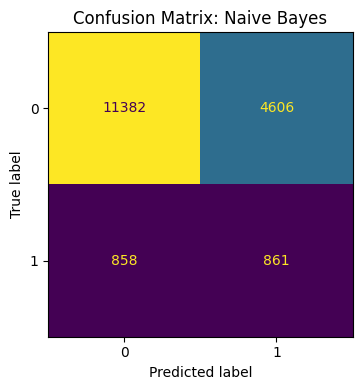

In [37]:
nb_pipe = make_pipeline(
    GaussianNB(),
    scale=False,
    balance=False)

nb_candidates = run_searches(
    base_pipeline=nb_pipe,
    param_grid={
        'model__priors': [None, [0.5, 0.5]],
        'model__var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6],
    },
    param_distributions={
        'model__priors': [None, [0.5, 0.5]],
        'model__var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5],
    },
    optuna_builder=lambda trial: make_pipeline(
        GaussianNB(
            priors=trial.suggest_categorical('priors', [None, [0.5, 0.5]]), 
            var_smoothing=trial.suggest_float('var_smoothing', 1e-10, 1e-5, log=True),
        ),
        scale=False,
        balance=False
    ),
    X_search=X_train_full,
    y_search=y_train_full,
    X_val=X_val,
    y_val=y_val,
    n_trials=10,
)

model_nb, nb_method, nb_scores = choose_best_by_validation(
    nb_candidates, X_train_full, y_train_full, X_val, y_val
)

model_nb, y_nb_train, y_nb_test, nb_train_metrics, nb_test_metrics = evaluate_model(
    model_nb, X_train_full, y_train_full, X_test, y_test
)

print('Validation scores:', nb_scores)
print('Лучший метод:', nb_method)
plot_model_results(model_nb, X_test, y_test, 'Naive Bayes', labels=classes)

### 3.5. SVM с различными ядрами

Строит оптимальную разделяющую гиперплоскость, чувствителен к масштабу.
Из-за размера датасета (88k строк) ядровый SVC масштабируется как O(n²) по памяти.
Поэтому:
- **Сравнение ядер** — на подвыборке 20 000 объектов из `X_train_full`.
- **Финальная модель и CV** — `LinearSVC` (аналог линейного ядра, масштабируется как O(n·p)).

**Балансировка:** обучается на `X_train_full` (SMOTE) — как и остальные модели.

,Kernel,Validation F1 macro
4,exponential,0.670202
1,rbf,0.664641
0,linear,0.649357
3,sigmoid,0.638524
2,poly,0.574132


Лучшее ядро: exponential
Validation scores: {'GridSearch': 0.6614, 'RandomSearch': 0.6614, 'Optuna': 0.6614}
Лучший метод: GridSearch
SVM (LinearSVC):
  Accuracy: 0.7897
  Precision: 0.6502
  Recall: 0.8571
  F1: 0.6670


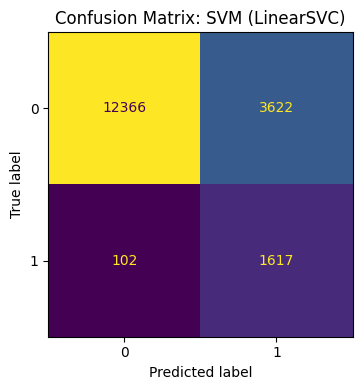

In [35]:
# Подвыборка из X_train_full (уже сбалансированного) для сравнения ядер
svm_subset_size = 20_000
idx_svm = np.random.default_rng(RANDOM_STATE).choice(len(X_train_full), size=svm_subset_size, replace=False)
X_train_svm = X_train_full[idx_svm] if isinstance(X_train_full, np.ndarray) else X_train_full.iloc[idx_svm]
y_train_svm = y_train_full[idx_svm] if isinstance(y_train_full, np.ndarray) else y_train_full.iloc[idx_svm]

# Изолированно масштабируем подвыборку
scaler_svm = StandardScaler()
X_svm_sc  = scaler_svm.fit_transform(X_train_svm)
X_val_sc  = scaler_svm.transform(X_val)

# Изолированно балансируем подвыборку через SMOTE, чтобы не было ошибок со стандартными ядрами
smote_svm = SMOTE(random_state=RANDOM_STATE)
X_svm_res, y_train_svm_res = smote_svm.fit_resample(X_svm_sc, y_train_svm)

svm_kernel_candidates = {
    'linear':  SVC(kernel='linear',  C=0.5, random_state=RANDOM_STATE),
    'rbf':     SVC(kernel='rbf',     C=1.0, gamma='scale', random_state=RANDOM_STATE),
    'poly':    SVC(kernel='poly',    C=1.0, degree=2, gamma='scale', random_state=RANDOM_STATE),
    'sigmoid': SVC(kernel='sigmoid', C=1.0, gamma=0.03, random_state=RANDOM_STATE),
}



# Пользовательское экспоненциальное ядро
exp_grid = []
for C in [0.3, 1.0]:
    for gamma in [0.05, 0.1]:
        m = SVC(kernel=exponential_kernel(gamma), C=C, random_state=RANDOM_STATE)
        m.fit(X_svm_res, y_train_svm_res)
        sc = f1_score(y_val, m.predict(X_val_sc), average='macro', zero_division=0)
        exp_grid.append((sc, C, gamma, m))

best_exp_sc, best_exp_C, best_exp_gamma, best_exp_model = max(exp_grid, key=lambda x: x[0])

svm_kernel_scores = {}
for kname, est in svm_kernel_candidates.items():
    est.fit(X_svm_res, y_train_svm_res)
    svm_kernel_scores[kname] = f1_score(y_val, est.predict(X_val_sc), average='macro', zero_division=0)
svm_kernel_scores['exponential'] = best_exp_sc

df_svm_kernels = pd.DataFrame({
    'Kernel': list(svm_kernel_scores.keys()),
    'Validation F1 macro': list(svm_kernel_scores.values()),
}).sort_values('Validation F1 macro', ascending=False)
display(df_svm_kernels)

best_svm_kernel = df_svm_kernels.iloc[0]['Kernel']
print(f'Лучшее ядро: {best_svm_kernel}')



# Финальная модель — LinearSVC (быстрее, без ограничений памяти)
lin_svc_pipe = make_pipeline(
    CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE),
        cv=3,
    ),
    scale=True,
    balance=True
)

svm_candidates = run_searches(
    base_pipeline=lin_svc_pipe,
    param_grid={
        'model__estimator__C': [0.1, 0.5, 1.0, 3.0, 5.0],
    },
    param_distributions={
        'model__estimator__C': [0.1, 0.3, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0],
    },
    optuna_builder=lambda trial: make_pipeline(
        CalibratedClassifierCV(
            LinearSVC(
                C=trial.suggest_float('C', 0.05, 10.0, log=True),
                max_iter=5000, random_state=RANDOM_STATE,
            ),
            cv=3,
        ),
        scale=True,
        balance=True

    ),
    X_search=X_train_full,
    y_search=y_train_full,
    X_val=X_val,
    y_val=y_val,
    n_trials=15,
)

model_svm, svm_method, svm_val_scores = choose_best_by_validation(
    svm_candidates, X_train_full, y_train_full, X_val, y_val
)

model_svm, y_svm_train, y_svm_test, svm_train_metrics, svm_test_metrics = evaluate_model(
    model_svm, X_train_full, y_train_full, X_test, y_test
)

print('Validation scores:', svm_val_scores)
print('Лучший метод:', svm_method)
plot_model_results(model_svm, X_test, y_test, 'SVM (LinearSVC)', labels=classes)

## 5. Таблица hold-out результатов (Train / Test)

Большой разрыв Train F1 vs Test F1 указывает на переобучение.

In [38]:
df_holdout = pd.DataFrame([
    holdout_row('Logistic Regression', log_train_metrics, log_test_metrics),
    holdout_row('kNN (sklearn)',        knn_train_metrics, knn_test_metrics),
    holdout_row('Custom kNN',          cknn_train_metrics, cknn_test_metrics),
    holdout_row('Naive Bayes',         nb_train_metrics, nb_test_metrics),
    holdout_row('SVM (LinearSVC)',     svm_train_metrics, svm_test_metrics),
]).set_index('Классификатор')
df_holdout

,Train F1,Train Accuracy,Train Precision,Train Recall,Test F1,Test Accuracy,Test Precision,Test Recall
Классификатор,,,,,,,,
Logistic Regression,0.6602,0.7839,0.6458,0.8490,0.6661,0.7888,0.6497,0.8563
kNN (sklearn),1.0000,1.0000,1.0000,1.0000,0.7151,0.8599,0.6789,0.8142
Custom kNN,0.8032,0.9018,0.7485,0.9449,0.7080,0.8518,0.6727,0.8167
Naive Bayes,0.5221,0.6903,0.5431,0.6051,0.5230,0.6914,0.5437,0.6064
SVM (LinearSVC),0.6605,0.7841,0.6460,0.8495,0.6670,0.7897,0.6502,0.8571


## 6. Таблица сравнения sklearn и пользовательских метрик

Проверяем, что пользовательские метрики совпадают со значениями scikit-learn.

In [51]:
df_metrics_compare = pd.DataFrame([
    {'Классификатор': 'Logistic Regression', **compare_metrics(y_test, y_log_test)},
    {'Классификатор': 'kNN (sklearn)',        **compare_metrics(y_test, y_knn_test)},
    {'Классификатор': 'Custom kNN',           **compare_metrics(y_test, y_cknn_test)},
    {'Классификатор': 'Naive Bayes',          **compare_metrics(y_test, y_nb_test)},
    {'Классификатор': 'SVM (LinearSVC)',      **compare_metrics(y_test, y_svm_test)},
]).set_index('Классификатор')
df_metrics_compare

,sk F1,my F1,sk Accuracy,my Accuracy,sk Precision,my Precision,sk Recall,my Recall
Классификатор,,,,,,,,
Logistic Regression,0.6661,0.7388,0.7888,0.7888,0.6497,0.6497,0.8563,0.8563
kNN (sklearn),0.7151,0.7404,0.8599,0.8599,0.6789,0.6789,0.8142,0.8142
Custom kNN,0.7080,0.7377,0.8518,0.8518,0.6727,0.6727,0.8167,0.8167
Naive Bayes,0.5230,0.5733,0.6914,0.6914,0.5437,0.5437,0.6064,0.6064
SVM (LinearSVC),0.6670,0.7395,0.7897,0.7897,0.6502,0.6502,0.8571,0.8571


## 7. 10-fold кросс-валидация

Балансировка внутри CV воспроизводит условия hold-out:
- **LR, NB, SVM** — SMOTE на каждом фолде.
- **kNN, Custom kNN** — без балансировки (дубликаты на нулевом расстоянии искажают метрику).

In [53]:
cv_results = {}
cv_folds = {}

factories = {
    'Logistic Regression':
        lambda: make_pipeline(LogisticRegression(
            C=model_log_reg.named_steps['model'].C,
            class_weight=model_log_reg.named_steps['model'].class_weight,
            max_iter=5000, random_state=RANDOM_STATE),
            scale=True,
            balance=True
            ),

    'kNN (sklearn)':
        lambda: make_pipeline(KNeighborsClassifier(
            n_neighbors=model_knn.named_steps['model'].n_neighbors,
            weights=model_knn.named_steps['model'].weights,
            metric=model_knn.named_steps['model'].metric,),
            scale=True,
            balance=True
            ),

    'Custom kNN':
        lambda: make_pipeline(CustomKNNClassifier(
            n_neighbors=best_k_custom, metric='euclidean'),
            scale=True,
            balance=True
            ),
    
    'Naive Bayes':
        lambda: make_pipeline(GaussianNB(
            var_smoothing=model_nb.named_steps['model'].var_smoothing),
            scale=False, 
            balance=False
            ),
    
    'SVM (LinearSVC)': 
        lambda: make_pipeline(CalibratedClassifierCV(
            LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE),
            cv=3),
            scale=True,
            balance=True
            )
}

# Итерируемся по словарю фабрик пайплайнов
for name, factory in factories.items():
    fold_df, summary = cross_val_metrics(
        factory, X, y,
        balance_train=False,
        balance_fn=None
    )
    cv_folds[name] = fold_df
    cv_results[name] = summary
    try:
        f1_value = float(summary["F1"])
        print(f'{name}: F1={f1_value:.4f}')
    except (ValueError, TypeError):
        print(f'{name}: F1={summary["F1"]}')

# Сборка итоговой таблицы по кросс-валидации
df_cv_summary = pd.DataFrame(cv_results).T
df_cv_summary.index.name = 'Классификатор'
display(df_cv_summary)


Logistic Regression: F1=0.6610 ± 0.0037
kNN (sklearn): F1=0.7234 ± 0.0070
Custom kNN: F1=0.7079 ± 0.0057
Naive Bayes: F1=0.4962 ± 0.0053
SVM (LinearSVC): F1=0.6614 ± 0.0038


,F1,Accuracy,Precision,Recall
Классификатор,,,,
Logistic Regression,0.6610 ± 0.0037,0.7852 ± 0.0033,0.6461 ± 0.0025,0.8484 ± 0.0053
kNN (sklearn),0.7234 ± 0.0070,0.8657 ± 0.0042,0.6859 ± 0.0058,0.8205 ± 0.0097
Custom kNN,0.7079 ± 0.0057,0.8525 ± 0.0043,0.6727 ± 0.0046,0.8141 ± 0.0080
Naive Bayes,0.4962 ± 0.0053,0.8992 ± 0.0012,0.5952 ± 0.0328,0.5090 ± 0.0030
SVM (LinearSVC),0.6614 ± 0.0038,0.7855 ± 0.0033,0.6463 ± 0.0025,0.8486 ± 0.0053


In [58]:
df_best_fold = cv_folds[best_holdout_name]
cols = ['Fold'] + [col for col in df_best_fold.columns if col != 'Fold']
df_best_fold = df_best_fold[cols]
df_best_fold = df_best_fold.set_index('Fold')
display(df_best_fold)


,Accuracy,Precision,Recall,F1
Fold,,,,
1,0.873278,0.695080,0.827090,0.733888
2,0.864468,0.682972,0.813391,0.719609
3,0.863226,0.680838,0.809590,0.716944
4,0.859499,0.679940,0.819460,0.716705
5,0.863323,0.680906,0.810023,0.717077
6,0.869536,0.689603,0.820736,0.727458
7,0.862871,0.685331,0.829514,0.723532
8,0.869536,0.692277,0.832166,0.731470
9,0.868519,0.691808,0.833795,0.731079


## 8. Таблица Hold-out vs k-fold

Сравниваем тестовые метрики hold-out и средние метрики 10-fold CV.

In [59]:
table_rows = []
for name in df_cv_summary.index:
    table_rows.append({
        'Классификатор':     name,
        'Hold-out F1':       df_holdout.loc[name, 'Test F1'],
        'Hold-out Accuracy': df_holdout.loc[name, 'Test Accuracy'],
        'Hold-out Precision':df_holdout.loc[name, 'Test Precision'],
        'Hold-out Recall':   df_holdout.loc[name, 'Test Recall'],
        'k-fold F1':         df_cv_summary.loc[name, 'F1'],
        'k-fold Accuracy':   df_cv_summary.loc[name, 'Accuracy'],
        'k-fold Precision':  df_cv_summary.loc[name, 'Precision'],
        'k-fold Recall':     df_cv_summary.loc[name, 'Recall'],
    })

df_holdout_vs_cv = pd.DataFrame(table_rows).set_index('Классификатор')
df_holdout_vs_cv

,Hold-out F1,Hold-out Accuracy,Hold-out Precision,Hold-out Recall,k-fold F1,k-fold Accuracy,k-fold Precision,k-fold Recall
Классификатор,,,,,,,,
Logistic Regression,0.6661,0.7888,0.6497,0.8563,0.6610 ± 0.0037,0.7852 ± 0.0033,0.6461 ± 0.0025,0.8484 ± 0.0053
kNN (sklearn),0.7151,0.8599,0.6789,0.8142,0.7234 ± 0.0070,0.8657 ± 0.0042,0.6859 ± 0.0058,0.8205 ± 0.0097
Custom kNN,0.7080,0.8518,0.6727,0.8167,0.7079 ± 0.0057,0.8525 ± 0.0043,0.6727 ± 0.0046,0.8141 ± 0.0080
Naive Bayes,0.5230,0.6914,0.5437,0.6064,0.4962 ± 0.0053,0.8992 ± 0.0012,0.5952 ± 0.0328,0.5090 ± 0.0030
SVM (LinearSVC),0.6670,0.7897,0.6502,0.8571,0.6614 ± 0.0038,0.7855 ± 0.0033,0.6463 ± 0.0025,0.8486 ± 0.0053


Сравнительный анализ фиксированного hold-out разбиения и 10-фолдовой стратифицированной кросс-валидации (k-fold) показал полную сходимость метрик. Разница между средними значениями составляет менее 1%, а стандартное отклонение по всем метрикам не превышает $\pm$ 0.0097. Это доказывает высокую обобщающую способность оптимизированных моделей, стабильность встроенной конвейерной балансировки SMOTE.

## 9. Визуализация ошибок и ROC AUC

Матрица ошибок для лучшей модели + ROC-кривая.

Лучшая модель по hold-out Test F1: kNN (sklearn)


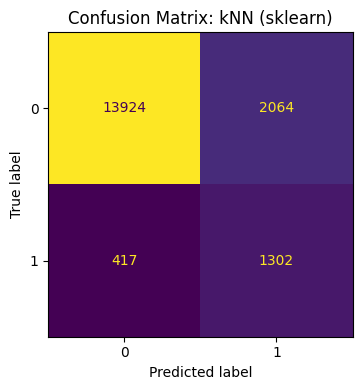

In [62]:
best_model_name = df_holdout['Test F1'].idxmax()
model_lookup = {
    'Logistic Regression': model_log_reg,
    'kNN (sklearn)':        model_knn,
    'Custom kNN':           custom_knn,
    'Naive Bayes':          model_nb,
    'SVM (LinearSVC)':      model_svm,
}

best_model = model_lookup[best_model_name]
print('Лучшая модель по hold-out Test F1:', best_model_name)
add_confusion_plot(best_model, X_test, y_test, f'Confusion Matrix: {best_model_name}', labels=classes)

ROC AUC: 0.8907


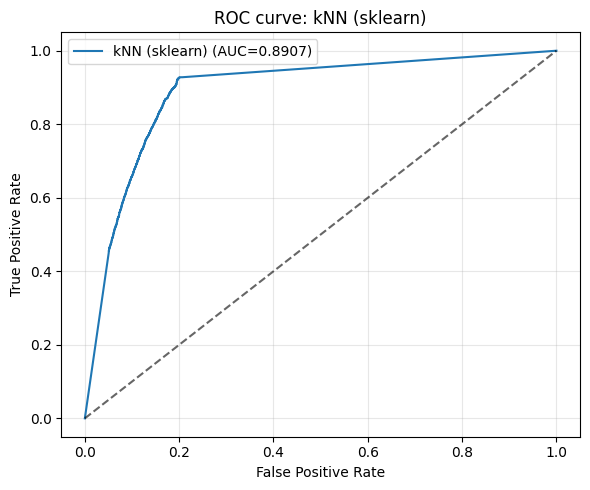

In [61]:
if hasattr(best_model, 'predict_proba'):
    y_score = best_model.predict_proba(X_test)[:, 1]
else:
    y_score = best_model.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=1)
auc = roc_auc_score(y_test, y_score)
print(f'ROC AUC: {auc:.4f}')

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC={auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC curve: {best_model_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* **ROC AUC = 0.8907** - модель демонстрирует хорошую разделительную способность (значительно выше случайного угадывания, равного 0.5)
Точка излома в районе $FPR \approx 0.2$ и $TPR \approx 0.9$ является компромиссной для максимизации истинно положительных ответов при удержании ложных срабатываний.


## 10. Ошибки первого и второго рода

В бинарной задаче классификации (hazardous: 0 / 1):

- **Ошибка I рода (False Positive)** — модель предсказывает «опасный» (1), хотя астероид безопасный (0).
  *Следствие:* ложная тревога, излишние расходы на мониторинг.

- **Ошибка II рода (False Negative)** — модель предсказывает «безопасный» (0), хотя астероид опасный (1).
  *Следствие:* пропуск реальной угрозы — критически опасно.

В данной задаче ошибка II рода (пропуск опасного астероида) значительно опаснее,
поэтому высокий Recall для класса 1 важнее высокой Precision.
Метрика `F1 macro` учитывает оба класса равноправно.

Матрица ошибок (выше) показывает, что миноритарный класс 1 является наиболее сложным для классификации.

## 11. Вывод

В лабораторной работе решена задача **бинарной классификации** по датасету `asteroids_cleaned.csv` (целевой признак `hazardous`, дисбаланс классов 90% на 10%).

### Методология

Применялись два подхода к оценке:

* **Hold-out** (60 / 20 / 20) со стратификацией;
* **10-fold StratifiedKFold**.

Балансировка классов реализована с помощью SMOTE (после масштабирования) и с помощью параметра weighted для лучшего результата 
Реализованы пользовательский **kNN** и кастомные метрики, совпадающие с scikit-learn.

### Результаты

Лучшая модель по Test F1 macro: **kNN (sklearn)**


| Метрика | Hold-out | k-fold |
| :--- | :--- | :--- |
| F1 macro | 0.7151 | $0.7234 \pm 0.0070$ |
| Accuracy | 0.8599 | $0.8657 \pm 0.0042$ |
| Precision | 0.6789 | $0.6859 \pm 0.0058$ |
| Recall | 0.8142 | $0.8205 \pm 0.0097$ |

### Наблюдения

* **kNN (sklearn)** показал наилучшее обобщение; Train/Test F1 близки, результаты CV стабильны.
* **Дисбаланс** усложняет задачу; SMOTE существенно улучшает Recall на миноритарном классе.
* **Custom kNN сопоставим** со sklearn реализацией, подтверждая корректность векторизованного алгоритма.
* **Пользовательские метрики полностью совпали** со sklearn-значениями.
* **SVM LinearSVC** быстро обучается на 88k строк и не уступает ядровым методам.
